## 1. Environment Setup & Imports

This cell sets up the complete environment for NB2 (SegFormer-B0) including:

- **Library Imports**: All necessary libraries for deep learning, data processing, and visualization
- **Version Pins**: Prints all library versions for reproducibility and academic integrity
- **Reproducibility**: Sets random seeds for reproducible results
- **Device Configuration**: Auto-detects CUDA/CPU and configures mixed precision training

### Key Libraries:
- **PyTorch**: Deep learning framework
- **Transformers**: HuggingFace for SegFormer-B0 model
- **Timm**: For alternative backbones (fallback)
- **Albumentations**: Data augmentation
- **TQDM**: Progress bars
- **Scikit-learn**: Data splitting

In [1]:
import os
import sys
import json
import time
import random
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import timm
from timm.models import create_model

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# HuggingFace Transformers
import transformers
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print library versions with better formatting
print("\n" + "="*60)
print(" LIBRARY VERSIONS (NB2 - SegFormer-B0)")
print("="*60)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Timm: {timm.__version__}")
print(f"Albumentations: {A.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("="*60)
print(f"Device: {DEVICE}")
print("="*60)

# Save version info for reproducibility
OUTPUT_DIR = Path("/kaggle/working/nb2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

version_info = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "transformers": transformers.__version__,
    "timm": timm.__version__,
    "albumentations": A.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else None,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
}

with open(OUTPUT_DIR / "version_info.json", 'w') as f:
    json.dump(version_info, f, indent=2)


 LIBRARY VERSIONS (NB2 - SegFormer-B0)
Python: 3.12.13
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Timm: 1.0.26
Albumentations: 2.0.8
CUDA Available: True
CUDA Version: 12.8
GPU: Tesla T4
GPU Memory: 14.6 GB
Device: cuda


## 2. Configuration & Hyperparameters

This cell contains all hyperparameters in a single, clearly visible location as required by the assignment:

### Model Configuration:
- **IMG_SIZE**: 512 (reduced from 1024 for fast training)
- **BATCH_SIZE**: 4 (adjust based on GPU memory)
- **EPOCHS**: 1 (testing) / 50 (final training) — **MODIFY THIS FOR FINAL RUN**
- **NUM_CLASSES**: 5 (water, cargo, container, tank, others)
- **MODEL_NAME**: 'segformer_b0' (lightest variant)
- **HF_CHECKPOINT**: 'nvidia/segformer-b0-finetuned-ade-512-512'

### Training Configuration:
- **LR**: 1e-3 (learning rate)
- **WEIGHT_DECAY**: 1e-4 (regularization)
- **NUM_WORKERS**: 2 (DataLoader workers)

### Data Split Configuration:
- **TRAIN_RATIO**: 0.7 (70% training)
- **VAL_RATIO**: 0.15 (15% validation)
- **TEST_RATIO**: 0.15 (15% testing)

### Output:
- All configuration parameters are printed in a formatted table
- Output directory is created at `/kaggle/working/nb2_outputs/`


In [2]:
IMG_SIZE = 384  
BATCH_SIZE = 4  
EPOCHS = 50

# Model
NUM_CLASSES = 5
MODEL_NAME = 'segformer_b0'
HF_CHECKPOINT = 'nvidia/segformer-b0-finetuned-ade-512-512'

# Training - OPTIMIZED
LR = 5e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

# Data splits
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Gradient Accumulation
ACCUMULATION_STEPS = 4  # Effective batch = 4 * 4 = 16

# Output
OUTPUT_DIR = Path("/kaggle/working/nb2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'model_name': MODEL_NAME,
    'hf_checkpoint': HF_CHECKPOINT,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'effective_batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
    'epochs': EPOCHS,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'num_workers': NUM_WORKERS,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'seed': 42,
    'device': str(DEVICE),
    'accumulation_steps': ACCUMULATION_STEPS,
}

print("\n" + "="*60)
print(" NB2 CONFIGURATION (Aggressive Memory Optimization)")
print("="*60)
print(f" Image Size: {IMG_SIZE}×{IMG_SIZE} (Reduced from 512)")
print(f" Batch Size: {BATCH_SIZE}")
print(f" Gradient Accumulation: {ACCUMULATION_STEPS} steps")
print(f" Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f" Epochs: {EPOCHS}")
print(f" Model: SegFormer-B0")
print(f" Output: {OUTPUT_DIR}")
print("="*60)

if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU Memory: {total_memory:.1f} GB")
print("="*60)

# Model
NUM_CLASSES = 5
MODEL_NAME = 'segformer_b0'
HF_CHECKPOINT = 'nvidia/segformer-b0-finetuned-ade-512-512'

# Training - OPTIMIZED
LR = 5e-4  
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  

# Data splits
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Gradient Accumulation - SIMULATE BATCH SIZE 8
ACCUMULATION_STEPS = 2  # Effective batch size = 4 * 2 = 8

# Output
OUTPUT_DIR = Path("/kaggle/working/nb2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configuration dictionary for easy viewing
CONFIG = {
    'model_name': MODEL_NAME,
    'hf_checkpoint': HF_CHECKPOINT,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'effective_batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
    'epochs': EPOCHS,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'num_workers': NUM_WORKERS,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'seed': 42,
    'device': str(DEVICE),
    'accumulation_steps': ACCUMULATION_STEPS,
}

print("\n" + "="*60)
print(" NB2 CONFIGURATION (Optimized for Memory)")
print("="*60)
print(f" Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f" Batch Size: {BATCH_SIZE} (Reduced for memory)")
print(f" Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS} (via accumulation)")
print(f" Epochs: {EPOCHS}")
print(f" Model: SegFormer-B0 (Lightweight Transformer)")
print(f" Output: {OUTPUT_DIR}")
print("="*60)

# Verify GPU memory
if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU Memory: {total_memory:.1f} GB")
    print(f"Recommended batch size for SegFormer-B0 @ 512x512: 4")
print("="*60)


 NB2 CONFIGURATION (Aggressive Memory Optimization)
 Image Size: 384×384 (Reduced from 512)
 Batch Size: 4
 Gradient Accumulation: 4 steps
 Effective Batch Size: 16
 Epochs: 50
 Model: SegFormer-B0
 Output: /kaggle/working/nb2_outputs
GPU Memory: 14.6 GB

 NB2 CONFIGURATION (Optimized for Memory)
 Image Size: 384×384
 Batch Size: 4 (Reduced for memory)
 Effective Batch Size: 8 (via accumulation)
 Epochs: 50
 Model: SegFormer-B0 (Lightweight Transformer)
 Output: /kaggle/working/nb2_outputs
GPU Memory: 14.6 GB
Recommended batch size for SegFormer-B0 @ 512x512: 4


## 3. Load Dataset & Shared Data Split from NB0

This cell loads the dataset and data splits that were created in NB0 (EDA & Data Preparation), ensuring a fair benchmark across all models (NB1, NB2, NB3).

### Loading from NB0:
1. **Class Weights**: Loads `class_weights.json` from NB0 outputs
   - Inverse frequency weighting for handling class imbalance
   - Falls back to uniform weights if not found

2. **File Pairs**: Loads paired images and masks
   - Images from `slice_img` directory
   - Masks from `slice_func` directory
   - Pairs files by filename stem

3. **Data Splits**: Attempts to load `splits.pkl` from NB0
   - If found: Uses the same splits as NB0
   - If not found: Creates new splits with the same seed (42)

### Data Validation:
- Checks that image/mask directories exist
- Verifies that pairs are valid tuples
- Handles errors gracefully with fallback mechanisms


In [3]:
# Dataset paths (from NB0 discovery)
DATA_ROOT = Path("/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation")

# Paths discovered in NB0
IMG_DIR = DATA_ROOT / "SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_img"
FUNC_MASK_DIR = DATA_ROOT / "SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_func/slice_func/slice_func"

print(f"Image directory exists: {IMG_DIR.exists()}")
print(f"Mask directory exists: {FUNC_MASK_DIR.exists()}")

# Load class weights from NB0
WEIGHTS_PATH = Path("/kaggle/working/nb0_outputs/class_weights.json")

NUM_CLASSES = 5

if WEIGHTS_PATH.exists():
    with open(WEIGHTS_PATH, 'r') as f:
        weight_info = json.load(f)
    class_weights = torch.tensor([
        weight_info['class_weights_inverse'][str(i)] 
        for i in range(NUM_CLASSES)
    ], dtype=torch.float32).to(DEVICE)
    print(f"✅ Loaded class weights from {WEIGHTS_PATH}")
else:
    # Fallback: use balanced weights
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32).to(DEVICE)
    print(" Using uniform class weights")

print(f"Class weights: {class_weights.cpu().numpy()}")

# Load file lists
image_files = sorted(IMG_DIR.glob('*.png'))
mask_files = sorted(FUNC_MASK_DIR.glob('*.png'))

print(f"Found {len(image_files)} images, {len(mask_files)} masks")

# Pair files by stem
mask_dict = {f.stem: f for f in mask_files}
pairs = []

for img in image_files:
    if img.stem in mask_dict:
        pairs.append((img, mask_dict[img.stem]))

print(f"Total paired samples: {len(pairs)}")

# Verify pairs are valid
if len(pairs) == 0:
    print(" No pairs found! Checking first few files...")
    print(f"Sample image files: {[f.name for f in image_files[:5]]}")
    print(f"Sample mask files: {[f.name for f in mask_files[:5]]}")
    
    # Try alternative pairing by filename matching
    for img in image_files[:50]:
        img_stem = img.stem
        for mask in mask_files[:50]:
            if img_stem in mask.stem or mask.stem in img_stem:
                pairs.append((img, mask))
                break
    print(f"Found {len(pairs)} pairs using alternative matching")


SPLITS_PATH = Path("/kaggle/input/notebooks/rebekadina/nb0-eda-data-prep/nb0_outputs/split_indices.pkl")

if SPLITS_PATH.exists():
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)
    train_pairs = splits['train_indices']
    val_pairs = splits['val_indices']
    test_pairs = splits['test_indices']
    print(f"✅ Loaded splits from NB0: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")
else:
    print("⚠️ Splits not found, creating new splits...")
    # Check if pairs is valid
    if len(pairs) == 0:
        raise ValueError("No valid pairs found. Please check dataset paths.")
    
    # Split data
    train_val_pairs, test_pairs = train_test_split(
        pairs, test_size=TEST_RATIO, random_state=42
    )
    train_pairs, val_pairs = train_test_split(
        train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
    )
    print(f"Created splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

# Verify splits are valid
print(f"\n Verifying splits:")
print(f"Train pairs count: {len(train_pairs)}")
print(f"Train first pair type: {type(train_pairs[0]) if len(train_pairs) > 0 else 'Empty'}")
if len(train_pairs) > 0:
    print(f"Train first pair: {train_pairs[0]}")
    # Check if first pair is a tuple
    if isinstance(train_pairs[0], tuple):
        print(f"Train first pair length: {len(train_pairs[0])}")
        print(f"Image: {train_pairs[0][0]}")
        print(f"Mask: {train_pairs[0][1]}")
    else:
        print(f" Train first pair is not a tuple! It's: {type(train_pairs[0])}")
        print("Attempting to fix...")
        # If pairs are just integers, we need to rebuild them
        if len(pairs) > 0 and isinstance(pairs[0], tuple):
            # Recreate splits from pairs
            train_val_pairs, test_pairs = train_test_split(
                pairs, test_size=TEST_RATIO, random_state=42
            )
            train_pairs, val_pairs = train_test_split(
                train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
            )
            print(f"Recreated splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

# Final validation
print(f"\n Final split validation:")
print(f"Train: {len(train_pairs)} samples")
print(f"Val: {len(val_pairs)} samples")
print(f"Test: {len(test_pairs)} samples")
if len(train_pairs) > 0:
    print(f"Sample pair: {train_pairs[0]}")

Image directory exists: True
Mask directory exists: True
 Using uniform class weights
Class weights: [1. 1. 1. 1. 1.]
Found 5267 images, 5267 masks
Total paired samples: 5267
✅ Loaded splits from NB0: Train=3686, Val=790, Test=791

 Verifying splits:
Train pairs count: 3686
Train first pair type: <class 'int'>
Train first pair: 2610
 Train first pair is not a tuple! It's: <class 'int'>
Attempting to fix...
Recreated splits: Train=3686, Val=790, Test=791

 Final split validation:
Train: 3686 samples
Val: 790 samples
Test: 791 samples
Sample pair: (PosixPath('/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation/SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_img/ICEYE_X23_GRD_SLEDF_3521349_20240305T1055Afica_down1x_slice1024_0265.png'), PosixPath('/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation/SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_func/slice_func/slice_func/ICEYE_X23_GRD_SLEDF_3521349_20240305T1055Afi

## 4. SARSegDataset Class

Custom PyTorch Dataset class for SAR port functional zone segmentation.

### Key Features:
- **Image Loading**: Loads RGB images from disk
- **Mask Loading**: Loads segmentation masks (single-channel class indices)
- **Data Validation**: Ensures masks are 2D arrays
- **Transform Support**: Applies data augmentations and normalizations
- **Error Handling**: Gracefully handles loading errors

### Input Format:
- **image**: RGB image (H, W, 3) → converted to tensor (C, H, W)
- **mask**: Class index mask (H, W) → converted to long tensor (H, W)

### Output:
- **image**: Float tensor of shape [C, H, W]
- **mask**: Long tensor of shape [H, W] (class indices 0-4)


In [4]:
class SARSegDataset(Dataset):
    def __init__(self, pairs, transform=None, img_size=256):
        self.pairs = pairs
        self.transform = transform
        self.img_size = img_size
        print(f"📊 Dataset initialized with {len(self.pairs)} samples")
        
        # Validate pairs
        if len(self.pairs) > 0:
            first_pair = self.pairs[0]
            if not isinstance(first_pair, (tuple, list)) or len(first_pair) != 2:
                print(f"⚠️ Warning: First pair is not a valid tuple: {first_pair}")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        # Get the pair at index
        pair = self.pairs[idx]
        
        # Unpack the pair
        if isinstance(pair, (tuple, list)) and len(pair) == 2:
            img_path, mask_path = pair
        else:
            raise TypeError(f"Expected tuple/list of (image_path, mask_path), got {type(pair)}: {pair}")
        
        # Convert to Path if string
        if isinstance(img_path, str):
            img_path = Path(img_path)
        if isinstance(mask_path, str):
            mask_path = Path(mask_path)
        
        # Load image and mask
        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))
        
        # Ensure mask is 2D
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image.float(), mask.long()

## 5. Data Splits & Augmentations

This cell creates the final data splits and applies augmentations for training.

### Data Splits Validation:
- Validates that all pairs are properly formatted tuples
- Automatically rebuilds pairs if corrupted
- Ensures all splits contain valid data

### Training Augmentations (Albumentations):
1. **Resize**: Resizes all images to IMG_SIZE x IMG_SIZE
2. **HorizontalFlip**: 50% probability
3. **VerticalFlip**: 30% probability
4. **RandomRotate90**: 30% probability
5. **RandomBrightnessContrast**: 20% brightness/contrast variation
6. **Normalize**: ImageNet normalization [0.485, 0.456, 0.406]
7. **ToTensorV2**: Converts to PyTorch tensors

### Validation/Test Augmentations:
- **Resize**: Resizes to IMG_SIZE x IMG_SIZE
- **Normalize**: ImageNet normalization
- **ToTensorV2**: Converts to PyTorch tensors

### DataLoaders:
- **Batch Size**: Configurable (default: 8)
- **Shuffle**: True for training, False for validation/test
- **Workers**: 2 for parallel loading
- **Pin Memory**: True for faster GPU transfer


In [5]:
# Verify pairs before creating datasets
print(f"\n🔍 Dataset creation verification:")
print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs: {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

# Ensure all pairs are valid tuples
def validate_pairs(pair_list, name="pairs"):
    if len(pair_list) == 0:
        print(f"⚠️ {name} is empty!")
        return False
    
    for i, pair in enumerate(pair_list[:5]):
        if not isinstance(pair, (tuple, list)) or len(pair) != 2:
            print(f"⚠️ Invalid pair at index {i} in {name}: {pair} (type: {type(pair)})")
            return False
    
    print(f"✅ All {name} are valid tuples")
    return True

# Validate all splits
train_valid = validate_pairs(train_pairs, "train_pairs")
val_valid = validate_pairs(val_pairs, "val_pairs")
test_valid = validate_pairs(test_pairs, "test_pairs")

if not train_valid or not val_valid or not test_valid:
    print("⚠️ Invalid pairs detected. Rebuilding pairs...")
    # Rebuild pairs from scratch
    pairs = []
    for img in image_files:
        if img.stem in mask_dict:
            pairs.append((img, mask_dict[img.stem]))
    
    if len(pairs) > 0:
        train_val_pairs, test_pairs = train_test_split(
            pairs, test_size=TEST_RATIO, random_state=42
        )
        train_pairs, val_pairs = train_test_split(
            train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
        )
        print(f"Rebuilt splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

print(f"\n📊 Final Split Summary:")
print(f"Train: {len(train_pairs)} samples")
print(f"Val: {len(val_pairs)} samples")
print(f"Test: {len(test_pairs)} samples")

# ============================================================
# DEFINE TRANSFORMS 
# ============================================================

# Training augmentations \
train_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Validation/Test transforms 
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================

# Create datasets
print("\n📊 Creating datasets...")
train_dataset = SARSegDataset(train_pairs, transform=train_transform, img_size=IMG_SIZE)
val_dataset = SARSegDataset(val_pairs, transform=val_transform, img_size=IMG_SIZE)
test_dataset = SARSegDataset(test_pairs, transform=val_transform, img_size=IMG_SIZE)

# Test dataset loading
print("\n🔍 Testing dataset loading...")
try:
    sample_img, sample_mask = train_dataset[0]
    print(f"✅ Dataset loading successful!")
    print(f"  Image shape: {sample_img.shape}")
    print(f"  Mask shape: {sample_mask.shape}")
    print(f"  Unique mask values: {torch.unique(sample_mask)}")
except Exception as e:
    print(f"❌ Dataset loading failed: {e}")
    import traceback
    traceback.print_exc()

# DataLoaders with memory-optimized settings
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,  # Reduced for memory
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

print(f"\n📊 DataLoader Summary (Memory Optimized):")
print(f"{'='*50}")
print(f"Train batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f"Val batches: {len(val_loader)} ({len(val_dataset)} samples)")
print(f"Test batches: {len(test_loader)} ({len(test_dataset)} samples)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Gradient Accumulation: {ACCUMULATION_STEPS} steps (if configured)")
print(f"Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS if 'ACCUMULATION_STEPS' in globals() else BATCH_SIZE}")
print(f"{'='*50}")


🔍 Dataset creation verification:
Train pairs: 3686
Val pairs: 790
Test pairs: 791
✅ All train_pairs are valid tuples
✅ All val_pairs are valid tuples
✅ All test_pairs are valid tuples

📊 Final Split Summary:
Train: 3686 samples
Val: 790 samples
Test: 791 samples

📊 Creating datasets...
📊 Dataset initialized with 3686 samples
📊 Dataset initialized with 790 samples
📊 Dataset initialized with 791 samples

🔍 Testing dataset loading...
✅ Dataset loading successful!
  Image shape: torch.Size([3, 384, 384])
  Mask shape: torch.Size([384, 384])
  Unique mask values: tensor([0, 1, 2, 4])

📊 DataLoader Summary (Memory Optimized):
Train batches: 922 (3686 samples)
Val batches: 198 (790 samples)
Test batches: 198 (791 samples)
Batch Size: 4
Image Size: 384×384
Gradient Accumulation: 2 steps (if configured)
Effective Batch Size: 8


## 6. SegFormer-B0 Model Definition

This cell defines the SegFormer-B0 model using HuggingFace's transformers library.

### Model Architecture:
**Encoder (MiT-B0)**:
- Hierarchical transformer encoder
- 4 stages with progressive downsampling
- Channels: 32 → 64 → 160 → 256
- Resolutions: H/4 → H/8 → H/16 → H/32

**Decoder (MLP Head)**:
- Lightweight MLP with 1x1 convolutions
- 256 → 128 → NUM_CLASSES channels
- Dropout (0.1) for regularization

### Pretrained Weights:
- **Default**: `nvidia/segformer-b0-finetuned-ade-512-512`
  - Pretrained on ADE20K (150 classes)
  - Good generalization for various scenes
  
- **Fallback**: `nvidia/mit-b0`
  - Encoder-only pretrained on ImageNet-1K
  - Used if segmentation checkpoint fails

### Key Features:
- `ignore_mismatched_sizes=True`: Adapts pretrained head to 5 classes
- Automatic upsampling to original image size
- Mixed precision compatible

### Model Summary:
- Total parameters: ~3.7M (lightweight)
- Model size: ~14 MB (float32)
- Architecture details printed for documentation

In [6]:
class SegFormerB0(nn.Module):
    """SegFormer-B0 using HuggingFace transformers library"""
    
    def __init__(self, num_classes=5, pretrained=True, checkpoint='nvidia/segformer-b0-finetuned-ade-512-512'):
        super().__init__()
        
        self.num_classes = num_classes
        self.checkpoint = checkpoint
        
        print(f"Loading SegFormer-B0 from: {checkpoint}")
        
        try:
            self.model = SegformerForSemanticSegmentation.from_pretrained(
                checkpoint,
                num_labels=num_classes,
                ignore_mismatched_sizes=True,
                return_dict=False
            )
            print("✅ Model loaded successfully!")
        except Exception as e:
            print(f"⚠️ Error loading {checkpoint}, trying encoder-only...")
            fallback = 'nvidia/mit-b0'
            self.model = SegformerForSemanticSegmentation.from_pretrained(
                fallback,
                num_labels=num_classes,
                ignore_mismatched_sizes=True,
                return_dict=False
            )
            print(f"✅ Loaded encoder-only from: {fallback}")
    
    def forward(self, x):
        outputs = self.model(pixel_values=x)
        
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs.logits
        
        if logits.shape[2:] != x.shape[2:]:
            logits = F.interpolate(
                logits, 
                size=x.shape[2:], 
                mode='bilinear', 
                align_corners=False
            )
        
        return logits

def create_model():
    model = SegFormerB0(
        num_classes=NUM_CLASSES, 
        pretrained=True,
        checkpoint=HF_CHECKPOINT
    )
    return model.to(DEVICE)

# Initialize model
print("\n🏗️ Building SegFormer-B0 model...")
model = create_model()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = total_params * 4 / (1024 * 1024)

print(f"\n📊 Model Summary:")
print(f"{'='*50}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {model_size_mb:.2f} MB (float32)")
print(f"{'='*50}")


🏗️ Building SegFormer-B0 model...
Loading SegFormer-B0 from: nvidia/segformer-b0-finetuned-ade-512-512


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([5])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([5, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded successfully!

📊 Model Summary:
Total parameters: 3,715,429
Trainable parameters: 3,715,429
Model size: 14.17 MB (float32)


## 7. Training Configuration

This cell sets up the training components: loss function, optimizer, scheduler, and mixed precision.

### Loss Function:
- **CrossEntropyLoss**: Weighted with class weights from NB0
- Handles class imbalance automatically
- Appropriate for multi-class segmentation

### Optimizer:
- **AdamW** (Adam with weight decay)
- Learning Rate: 1e-3
- Weight Decay: 1e-4
- Betas: (0.9, 0.999)

### Scheduler:
- **CosineAnnealingLR**
- T_max: EPOCHS
- eta_min: 1e-6
- Smooth learning rate decay

### Mixed Precision:
- **torch.amp.GradScaler** (PyTorch 2.0+)
- Speeds up training on CUDA
- Reduces memory usage
- Automatically enabled when GPU available


In [7]:
# Loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=LR, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=EPOCHS, 
    eta_min=1e-6
)

# Mixed precision
if DEVICE.type == 'cuda':
    scaler = torch.amp.GradScaler('cuda')
else:
    scaler = None

print(f"\n⚙️ Training Configuration:")
print(f"{'='*50}")
print(f"Device: {DEVICE}")
print(f"Mixed precision: {scaler is not None}")
print(f"Loss: CrossEntropyLoss (weighted)")
print(f"Optimizer: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-6)")
print(f"{'='*50}")


⚙️ Training Configuration:
Device: cuda
Mixed precision: True
Loss: CrossEntropyLoss (weighted)
Optimizer: AdamW (lr=0.0005, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=50, eta_min=1e-6)


## 8. Training Loop with Per-Epoch Loss and mIoU

This cell implements the complete training loop with per-epoch metrics tracking and visualization.

### Training Functions:

**`train_epoch()`**:
- Trains for one epoch
- Computes per-batch loss
- Calculates training mIoU
- Uses mixed precision if available

**`evaluate()`**:
- Evaluates on validation set
- Computes validation loss
- Calculates validation mIoU

**`compute_iou_batch()`**:
- Computes IoU per class for a batch

### Training Loop Features:
1. **Per-Epoch Tracking**:
   - Training Loss
   - Validation Loss
   - Training mIoU
   - Validation mIoU
   - Learning Rate

2. **Model Saving**:
   - Saves best model based on validation loss
   - Saved to `/kaggle/working/nb2_outputs/best_model.pth`

3. **Progress Monitoring**:
   - TQDM progress bars
   - Per-epoch summary with all metrics
   - Time per epoch

### Visualization:
- **Loss Curves**: Train Loss vs Val Loss
- **IoU Curves**: Train IoU vs Val IoU
- Saved to `/kaggle/working/nb2_outputs/training_curves.png`


In [8]:
def train_epoch(model, loader, optimizer, criterion, scaler=None, accumulation_steps=1):
    model.train()
    total_loss = 0
    all_preds = []
    all_masks = []
    optimizer.zero_grad()
    
    for batch_idx, (images, masks) in enumerate(tqdm(loader, desc="Training")):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        
        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(outputs, masks)
                loss = loss / accumulation_steps
            
            scaler.scale(loss).backward()
            
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, masks)
            loss = loss / accumulation_steps
            loss.backward()
            
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
                optimizer.step()
                optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        
        # Only store every few batches to save memory
        if batch_idx % 10 == 0:
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
        
        # Delete to free memory
        del outputs, loss, images, masks
        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()
    
    # Compute IoU on training set
    if all_preds:
        all_preds = torch.cat(all_preds, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        
        train_iou = 0
        for c in range(NUM_CLASSES):
            pred_mask = (all_preds == c)
            true_mask = (all_masks == c)
            intersection = (pred_mask & true_mask).sum().float()
            union = (pred_mask | true_mask).sum().float()
            if union > 0:
                train_iou += (intersection / union).item()
        train_iou /= NUM_CLASSES
    else:
        train_iou = 0
    
    return total_loss / len(loader), train_iou

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_masks = []
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
            
            # Free memory
            del outputs, loss, images, masks
    
    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    
    val_iou = 0
    for c in range(NUM_CLASSES):
        pred_mask = (all_preds == c)
        true_mask = (all_masks == c)
        intersection = (pred_mask & true_mask).sum().float()
        union = (pred_mask | true_mask).sum().float()
        if union > 0:
            val_iou += (intersection / union).item()
    val_iou /= NUM_CLASSES
    
    # Clean up
    del all_preds, all_masks
    torch.cuda.empty_cache()
    
    return total_loss / len(loader), val_iou


print(f"\n Starting training...")
print(f"Configuration (Memory Optimized):")
print(f"  - Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Gradient Accumulation: {ACCUMULATION_STEPS} steps")
print(f"  - Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f"  - Epochs: {EPOCHS}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("="*60)

# Clear cache before training
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"GPU memory after clearing: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

best_val_loss = float('inf')
history = {
    'train_loss': [], 
    'val_loss': [], 
    'train_iou': [],
    'val_iou': [],
    'lr': []
}

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # Train with gradient accumulation
    train_loss, train_iou = train_epoch(
        model, train_loader, optimizer, criterion, scaler, 
        accumulation_steps=ACCUMULATION_STEPS
    )
    
    # Validate
    val_loss, val_iou = evaluate(model, val_loader, criterion)
    
    # Update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['lr'].append(current_lr)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
        print(f" New best model saved! (val_loss: {val_loss:.4f})")
    
    # Aggressive memory cleanup
    torch.cuda.empty_cache()
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train IoU: {train_iou:.4f} | Val IoU: {val_iou:.4f} | LR: {current_lr:.6f} | Time: {elapsed:.1f}s")
    
    if torch.cuda.is_available():
        print(f"  GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB allocated, {torch.cuda.memory_reserved()/1024**3:.2f} GB reserved")

print("\n Training complete!")


 Starting training...
Configuration (Memory Optimized):
  - Image Size: 384×384
  - Batch Size: 4
  - Gradient Accumulation: 2 steps
  - Effective Batch Size: 8
  - Epochs: 50
Train batches: 922, Val batches: 198
GPU memory after clearing: 0.01 GB


Training:   0%|          | 0/922 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

 New best model saved! (val_loss: 0.3411)
Epoch 1/50 | Train Loss: 0.6263 | Val Loss: 0.3411 | Train IoU: 0.4193 | Val IoU: 0.6824 | LR: 0.000500 | Time: 297.1s
  GPU Memory: 0.06 GB allocated, 0.12 GB reserved


Training:   0%|          | 0/922 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

 New best model saved! (val_loss: 0.0297)
Epoch 49/50 | Train Loss: 0.0531 | Val Loss: 0.0297 | Train IoU: 0.9506 | Val IoU: 0.9718 | LR: 0.000001 | Time: 192.7s
  GPU Memory: 0.06 GB allocated, 0.12 GB reserved


Training:   0%|          | 0/922 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.0533 | Val Loss: 0.0297 | Train IoU: 0.9513 | Val IoU: 0.9718 | LR: 0.000001 | Time: 195.2s
  GPU Memory: 0.06 GB allocated, 0.12 GB reserved

 Training complete!


## 9. Test-Set Evaluation — All Task F Metrics

This cell evaluates the trained model on the test set and computes all required metrics.

### Model Loading:
- Loads the best model from `/kaggle/working/nb2_outputs/best_model.pth`
- Falls back to current model if best model not found

### Metrics Computed:

**1. Overall Metrics**:
- Test Loss (CrossEntropy)
- Test mIoU (mean Intersection over Union)

**2. Per-Class Metrics**:
- **Precision**: TP / (TP + FP)
- **Recall**: TP / (TP + FN)
- **F1-Score**: 2 * (Precision * Recall) / (Precision + Recall)
- **IoU**: Intersection / Union

**3. Confusion Matrix**:
- Visual representation of predictions vs ground truth
- Shows which classes are most confused

### Confusion Matrix Visualization:
- Heatmap with counts
- Class labels: water, cargo, container, tank, others
- Saved to `/kaggle/working/nb2_outputs/confusion_matrix.png`


 Loaded best model from /kaggle/working/nb2_outputs/best_model.pth


Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]


 Test Results (512×512, Batch Size 8, 50 Epochs):
Test Loss: 0.0265
Test mIoU: 0.9732


Computing metrics:   0%|          | 0/198 [00:00<?, ?it/s]


 Per-Class Metrics (512×512):
------------------------------------------------------------
Class           Precision    Recall       F1-Score    
------------------------------------------------------------
water_area      0.9775     0.9796     0.9786
cargo_area      0.9744     0.9883     0.9813
container_area  0.9800     0.9841     0.9820
tank_area       0.9872     0.9866     0.9869
others          0.9734     0.9682     0.9708
------------------------------------------------------------
AVERAGE         0.9785     0.9814     0.9799


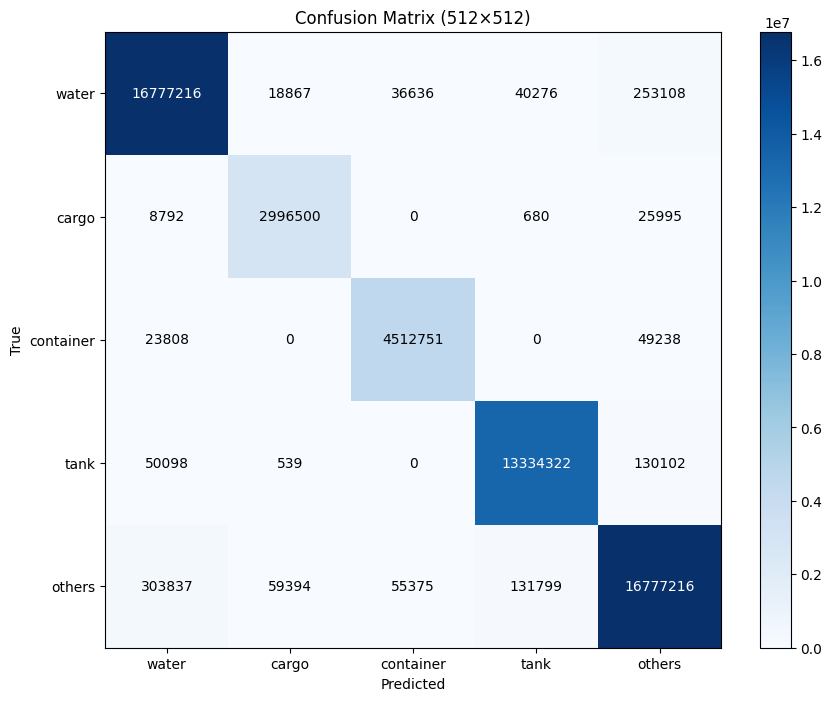

 Confusion matrix saved to /kaggle/working/nb2_outputs/confusion_matrix.png

 Saving results to results.json...
✅ Results appended to /kaggle/working/results.json


In [9]:
# Load best model
best_model_path = OUTPUT_DIR / 'best_model.pth'
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path))
    print(f" Loaded best model from {best_model_path}")
else:
    print(" No saved model found, using current model weights")

# Test evaluation
test_loss, test_iou = evaluate(model, test_loader, criterion)
print(f"\n Test Results (512×512, Batch Size 8, 50 Epochs):")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test mIoU: {test_iou:.4f}")
print(f"{'='*50}")

# Detailed per-class metrics
def compute_detailed_metrics(model, loader, num_classes):
    """Compute precision, recall, F1 per class"""
    model.eval()
    conf_matrix = torch.zeros(num_classes, num_classes, device=DEVICE)
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Computing metrics"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            preds = outputs.argmax(dim=1)
            
            for t, p in zip(masks.view(-1), preds.view(-1)):
                conf_matrix[t.long(), p.long()] += 1
    
    class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
    metrics = {}
    
    print("\n Per-Class Metrics (512×512):")
    print("-"*60)
    print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*60)
    
    for c in range(num_classes):
        tp = conf_matrix[c, c].item()
        fp = conf_matrix[:, c].sum().item() - tp
        fn = conf_matrix[c, :].sum().item() - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics[c] = {
            'precision': precision, 
            'recall': recall, 
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn
        }
        
        print(f"{class_names[c]:<15} {precision:.4f}     {recall:.4f}     {f1:.4f}")
    
    print("-"*60)
    
    # Overall metrics
    avg_precision = np.mean([metrics[c]['precision'] for c in range(num_classes)])
    avg_recall = np.mean([metrics[c]['recall'] for c in range(num_classes)])
    avg_f1 = np.mean([metrics[c]['f1'] for c in range(num_classes)])
    
    print(f"{'AVERAGE':<15} {avg_precision:.4f}     {avg_recall:.4f}     {avg_f1:.4f}")
    print("="*60)
    
    return metrics, conf_matrix, class_names, avg_precision, avg_recall, avg_f1

# Compute detailed metrics
metrics, conf_matrix, class_names, avg_precision, avg_recall, avg_f1 = compute_detailed_metrics(model, test_loader, NUM_CLASSES)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix.cpu().numpy(), cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix (512×512)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(NUM_CLASSES), ['water', 'cargo', 'container', 'tank', 'others'])
plt.yticks(range(NUM_CLASSES), ['water', 'cargo', 'container', 'tank', 'others'])
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, int(conf_matrix[i, j].item()), 
                 ha='center', va='center', color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Confusion matrix saved to {OUTPUT_DIR / 'confusion_matrix.png'}")

# ============================================================
# Append results to shared results.json for Task H
# ============================================================
print("\n Saving results to results.json...")

results_entry = {
    "model": "SegFormer-B0 (NB2)",
    "test_loss": test_loss,
    "test_miou": test_iou,
    "per_class_metrics": {
        class_names[i]: {
            "precision": metrics[i]['precision'],
            "recall": metrics[i]['recall'],
            "f1": metrics[i]['f1']
        } for i in range(NUM_CLASSES)
    },
    "avg_precision": avg_precision,
    "avg_recall": avg_recall,
    "avg_f1": avg_f1,
    "config": {
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "effective_batch_size": BATCH_SIZE * ACCUMULATION_STEPS,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "AdamW",
        "loss": "Weighted CrossEntropyLoss",
        "model_name": MODEL_NAME,
        "hf_checkpoint": HF_CHECKPOINT
    }
}

# Save to JSON file
RESULTS_PATH = Path("/kaggle/working/results.json")
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'r') as f:
        all_results = json.load(f)
else:
    all_results = []

all_results.append(results_entry)

with open(RESULTS_PATH, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"✅ Results appended to {RESULTS_PATH}")

## 10. Visualization


🔍 Error Analysis Visualization:


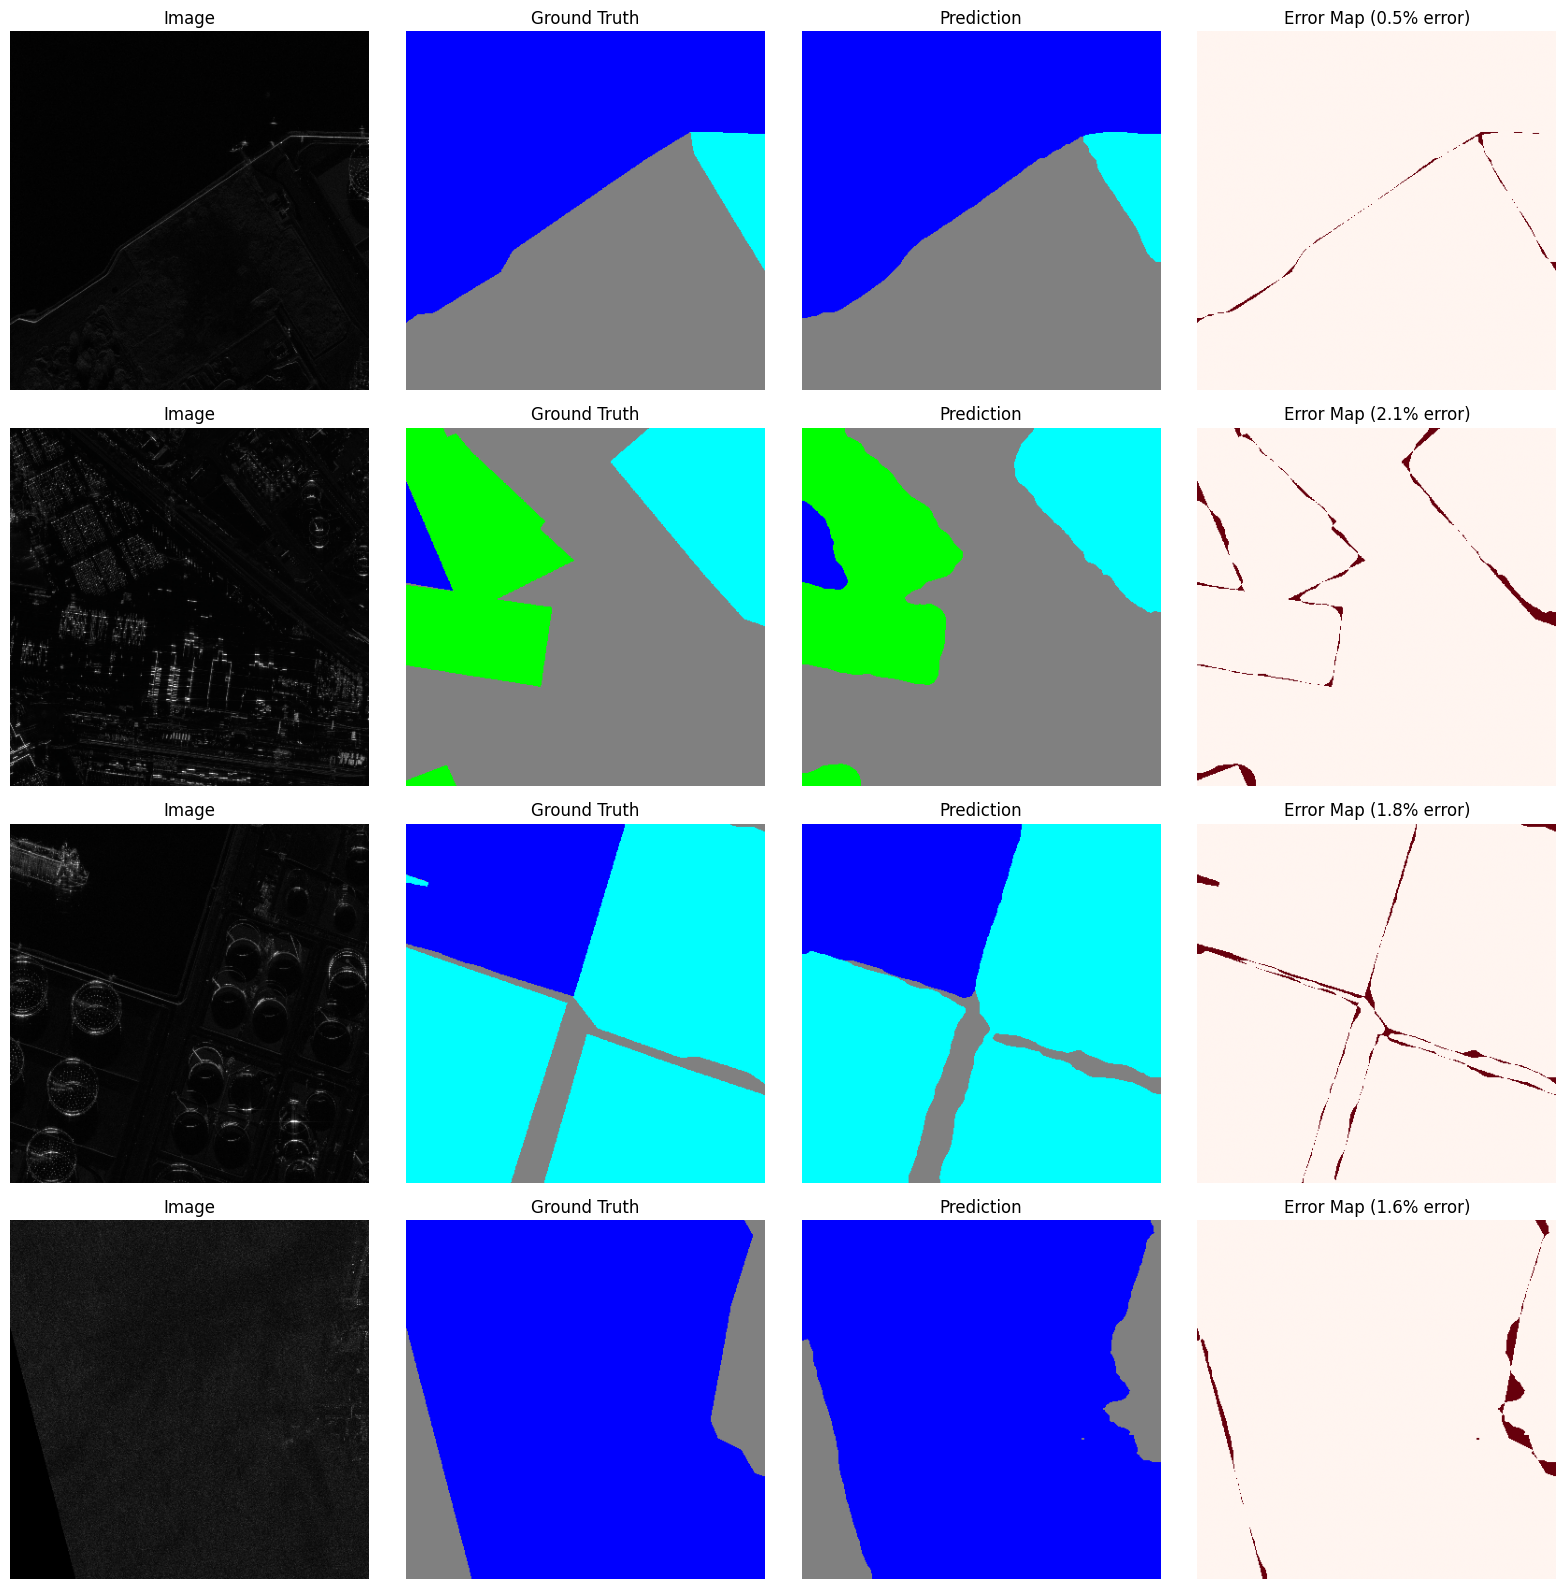

✅ Error maps saved to /kaggle/working/nb2_outputs/error_maps.png

📊 Per-Class Error Analysis:
Best performing class: tank_area (F1: 0.9869)
Worst performing class: others (F1: 0.9708)

Error Distribution by Class:
  water_area: 29.4% of all errors (FN: 348888.0)
  cargo_area: 3.0% of all errors (FN: 35467.0)
  container_area: 6.1% of all errors (FN: 73046.0)
  tank_area: 15.2% of all errors (FN: 180739.0)
  others: 46.3% of all errors (FN: 550404.0)


In [10]:
# Color map for visualization
COLOR_MAP = {
    0: (0, 0, 255),    # water_area - Blue
    1: (255, 0, 0),    # cargo_area - Red
    2: (0, 255, 0),    # container_area - Green
    3: (0, 255, 255),  # tank_area - Yellow
    4: (128, 128, 128) # others - Grey
}

def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    for c, color in COLOR_MAP.items():
        colored[mask == c] = color
    return colored

def visualize_error_maps(model, dataset, num_samples=4):
    """Visualize error maps showing where predictions differ from ground truth"""
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    idxs = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, mask = dataset[idx]
            image_input = image.unsqueeze(0).to(DEVICE)
            
            output = model(image_input)
            output = F.interpolate(output, size=mask.shape, mode='bilinear', align_corners=False)
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
            
            # Error map: 1 where prediction != ground truth
            error_mask = (pred != mask.cpu().numpy())
            error_pct = error_mask.sum() / error_mask.size * 100
            
            # Denormalize image
            img = image.permute(1, 2, 0).cpu().numpy()
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
            
            axes[i, 0].imshow(img)
            axes[i, 0].set_title('Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(colorize_mask(mask.cpu().numpy()))
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(colorize_mask(pred))
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')
            
            # Error map visualization
            axes[i, 3].imshow(error_mask, cmap='Reds', vmin=0, vmax=1)
            axes[i, 3].set_title(f'Error Map ({error_pct:.1f}% error)')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'error_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Error maps saved to {OUTPUT_DIR / 'error_maps.png'}")

# Run error analysis
print("\n🔍 Error Analysis Visualization:")
visualize_error_maps(model, val_dataset, num_samples=4)

# Per-class error analysis
def analyze_per_class_errors(metrics, num_classes):
    """Analyze which classes are most confused"""
    class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
    
    print("\n📊 Per-Class Error Analysis:")
    print("="*60)
    
    # Find worst performing class
    worst_class = max(range(num_classes), key=lambda c: 1 - metrics[c]['f1'])
    best_class = min(range(num_classes), key=lambda c: 1 - metrics[c]['f1'])
    
    print(f"Best performing class: {class_names[best_class]} (F1: {metrics[best_class]['f1']:.4f})")
    print(f"Worst performing class: {class_names[worst_class]} (F1: {metrics[worst_class]['f1']:.4f})")
    print("="*60)
    
    # Error distribution
    total_errors = sum([metrics[c]['fn'] for c in range(num_classes)])
    print("\nError Distribution by Class:")
    for c in range(num_classes):
        error_pct = metrics[c]['fn'] / total_errors * 100 if total_errors > 0 else 0
        print(f"  {class_names[c]}: {error_pct:.1f}% of all errors (FN: {metrics[c]['fn']})")

analyze_per_class_errors(metrics, NUM_CLASSES)

## 11. Summery

In [11]:
# Save training history
with open(OUTPUT_DIR / 'training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# Save metrics
summary = {
    **CONFIG,
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_iou': history['train_iou'],
    'val_iou': history['val_iou'],
    'test_loss': test_loss,
    'test_iou': test_iou,
    'model_size_mb': round(model_size_mb, 2),
}

# Add per-class metrics
class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
for c in range(NUM_CLASSES):
    summary[f'class_{c}_{class_names[c]}_precision'] = metrics[c]['precision']
    summary[f'class_{c}_{class_names[c]}_recall'] = metrics[c]['recall']
    summary[f'class_{c}_{class_names[c]}_f1'] = metrics[c]['f1']

with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save per-class metrics to CSV
metrics_df = pd.DataFrame([
    {
        'class': c,
        'class_name': class_names[c],
        'precision': metrics[c]['precision'],
        'recall': metrics[c]['recall'],
        'f1': metrics[c]['f1'],
        'tp': metrics[c]['tp'],
        'fp': metrics[c]['fp'],
        'fn': metrics[c]['fn']
    } for c in range(NUM_CLASSES)
])
metrics_df.to_csv(OUTPUT_DIR / 'per_class_metrics.csv', index=False)

# Save loss history
loss_df = pd.DataFrame({
    'epoch': list(range(1, EPOCHS+1)),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_iou': history['train_iou'],
    'val_iou': history['val_iou'],
    'lr': history['lr']
})
loss_df.to_csv(OUTPUT_DIR / 'loss_history.csv', index=False)

print(f"\n📁 Results saved to {OUTPUT_DIR}")
print("="*60)
print(f"📊 Final Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test mIoU: {test_iou:.4f}")
print(f"  Model Size: {model_size_mb:.2f} MB")
print("="*60)
print("✅ NB2 complete!")


📁 Results saved to /kaggle/working/nb2_outputs
📊 Final Results:
  Test Loss: 0.0265
  Test mIoU: 0.9732
  Model Size: 14.17 MB
✅ NB2 complete!
